In [2]:
"""
DESCRIPTION: 
    - import necessary libraries 
    - read initial CSVs and create dataframes 
"""


import sys, os
sys.path.append(os.path.abspath("../src"))


from utils.io_utils import load_csv_folder

from utils.preprocess_utils import extract_base_freethrow_name
from utils.preprocess_utils import combine_angles_dfs
from utils.preprocess_utils import filter_angles_kalman
from utils.preprocess_utils import crop_to_freethrow
from utils.preprocess_utils import align_by_reference # TODO remove once below ones work 

from utils.align_freethrows_utils import align_by_lowest_point
from utils.align_freethrows_utils import align_by_release_point
from utils.align_freethrows_utils import align_by_min_unsigned_area
from utils.align_freethrows_utils import align_by_min_signed_area

from utils.analyze_freethrows_utils import analyze_freethrow_durations
from utils.analyze_freethrows_utils import analyze_release_timing
from utils.analyze_freethrows_utils import analyze_release_angles

from utils.visualize_freethrow_utils import FreeThrowVisualizer

import glob
import yaml
import pandas as pd
import numpy as np
# import matplotlib as plt
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import norm
import importlib
import my_plots
importlib.reload(my_plots)
import re
from pathlib import Path


project_root = Path().resolve().parent

project_cfg_path = project_root / "project_config.yaml"
with open(project_cfg_path, "r") as f:
    project_cfg = yaml.safe_load(f)


# ----------
# Constants
# ----------

ATHLETE = project_cfg["athlete"]
SESSION = project_cfg["session"]
PRINT_DFS = False

# === CONFIG ===
DISPLAY_ELBOW_FLEX_L = False
DISPLAY_ELBOW_FLEX_R = True
DISPLAY_SHOULDER_FLEX_L = False
DISPLAY_SHOULDER_FLEX_R = False
DISPLAY_HIP_FLEX_L = False
DISPLAY_HIP_FLEX_R = False
DISPLAY_KNEE_FLEX_L = False
DISPLAY_KNEE_FLEX_R = False
DISPLAY_ANKLE_FLEX_L = False
DISPLAY_ANKLE_FLEX_R = False

# === Dictionary to hold flags ===
joint_flags = {
    "elbow_flex_l": DISPLAY_ELBOW_FLEX_L,
    "elbow_flex_r": DISPLAY_ELBOW_FLEX_R,
    "shoulder_flex_l": DISPLAY_SHOULDER_FLEX_L,
    "shoulder_flex_r": DISPLAY_SHOULDER_FLEX_R,
    "hip_flex_l": DISPLAY_HIP_FLEX_L,
    "hip_flex_r": DISPLAY_HIP_FLEX_R,
    "knee_flex_l": DISPLAY_KNEE_FLEX_L,
    "knee_flex_r": DISPLAY_KNEE_FLEX_R,
    "ankle_flex_l": DISPLAY_ANKLE_FLEX_L,
    "ankle_flex_r": DISPLAY_ANKLE_FLEX_R
}

selected_joints = [joint for joint, flag in joint_flags.items() if flag]

# ----------
# Paths
# ----------

metrics_path = Path(f"../data/{ATHLETE}/{SESSION}/metrics")
keypoints_path = metrics_path / "3d_keypoints"
angles_path = metrics_path / "3d_angles"
outcomes_path = metrics_path / "outcomes.csv"
phases_path = metrics_path / "freethrow_phases.csv"

# ----------
# Single CSV Files
# ----------

outcomes_df: pd.DataFrame = pd.read_csv(outcomes_path)
raw_phases_df: pd.DataFrame = pd.read_csv(phases_path)

# create new phased_df based on phases_df cropping
cropped_phases_df = pd.DataFrame()
cropped_phases_df["file"] = raw_phases_df["file"]
cropped_phases_df["cropped_first_frame"] = 0
cropped_phases_df["cropped_release_frame"] = (
    raw_phases_df["raw_release_frame"] - raw_phases_df["raw_windup_start"]
)
cropped_phases_df["cropped_last_frame"] = (
    raw_phases_df["raw_followthrough_end"] - raw_phases_df["raw_windup_start"]
)

# ----------
# dictionaries, str is freethrow name with corresponding dataFrame
# ----------

raw_keypoints_dfs: dict[str, pd.DataFrame] = load_csv_folder(keypoints_path)
raw_angles_dfs: dict[str, pd.DataFrame] = load_csv_folder(angles_path)

# TODO smoothed keypoints 
filtered_angles_dfs = filter_angles_kalman(raw_angles_dfs)

# TODO cropped keypoints 
filtered_cropped_angles_dfs: dict[str, pd.DataFrame] = crop_to_freethrow(filtered_angles_dfs, raw_phases_df) #might ruin data...
cropped_angles_dfs = crop_to_freethrow(raw_angles_dfs, raw_phases_df)

# TODO aligned keypoints 
aligned_lowest_point_dfs, lowest_point_log_df = align_by_lowest_point(cropped_angles_dfs)
aligned_release_point_dfs, release_point_log_df = align_by_release_point(cropped_angles_dfs, cropped_phases_df)
aligned_unsigned_area_dfs, unsigned_area_log_df = align_by_min_unsigned_area(cropped_angles_dfs)
aligned_signed_area_dfs, signed_area_log_df = align_by_min_signed_area(cropped_angles_dfs)


if PRINT_DFS:
    
    print("\n===============================================================")

    print("\n---outcomes information---")
    print(f"📊 Outcomes shape: {outcomes_df.shape} (rows, columns)") 

    print("📊 Outcomes head: (first 5 rows)")
    display(outcomes_df.head())

    print(f"📊 Outcomes columns: {outcomes_df.columns}") 

    print("\n===============================================================")

    print("\n---phases information---")
    print(f" Phases shape: {cropped_phases_df.shape} (rows, columns)")

    print(" Phases head: (first 5 rows)") 
    display(cropped_phases_df.head())

    print(f" Phases columns: {cropped_phases_df.columns}") 

    print("\n===============================================================")

    print("\n---raw_keypoints information---")
    print(f"✅ Loaded {len(raw_keypoints_dfs)} keypoint files")
    print(f"First five keypoint files: {list(raw_keypoints_dfs.keys())[:5]}")
    for name, df in list(raw_keypoints_dfs.items())[:1]:
        print(f"\n=== Keypoints: {name} ===")
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head())


    print("\n===============================================================")

    print("\n---cropped angles_df information---")
    for file_name in list(cropped_angles_dfs.keys())[:2]:
        df = cropped_angles_dfs[file_name]
        print(f"\n=== {file_name} ===")
        display(df.head())

    print("\n===============================================================")\
    
    # TODO aligned types go here eventually?



In [3]:
# ================================================
# STEP 1 — Compute mean/std bands for alignment set
# ================================================

def compute_mean_std_for_alignment(dfs_dict, joint_names):
    """
    Computes mean, std, upper, lower curves for each joint
    across all throws in dfs_dict.
    
    Returns:
        dict[joint_name] = {
            "mean": ...,
            "std": ...,
            "upper": ...,
            "lower": ...,
            "curves": 2D array of padded curves,
            "x": x-axis array
        }
    """
    results = {}

    for joint in joint_names:
        curves = []
        # Collect curves
        for file, df in dfs_dict.items():
            if joint not in df.columns:
                continue
            curves.append(df[joint].to_numpy())

        if not curves:
            continue

        # Pad shorter throws with NaN
        max_len = max(len(c) for c in curves)
        padded = [
            np.pad(c, (0, max_len - len(c)), constant_values=np.nan)
            for c in curves
        ]
        padded = np.vstack(padded)

        mean_curve = np.nanmean(padded, axis=0)
        std_curve  = np.nanstd(padded, axis=0)
        upper = mean_curve + std_curve
        lower = mean_curve - std_curve
        x = np.arange(max_len)

        results[joint] = {
            "curves": padded,
            "mean": mean_curve,
            "std": std_curve,
            "upper": upper,
            "lower": lower,
            "x": x,
        }

    return results


# ==== CALL IT HERE ====

joint_names = selected_joints  # from your earlier config
stats_unsigned_area = compute_mean_std_for_alignment(
    aligned_unsigned_area_dfs,
    joint_names
)

print("Computed stats for joints:", list(stats_unsigned_area.keys()))



Computed stats for joints: ['elbow_flex_r']


/var/folders/9c/hhbymx8x59sbkqhbr0qtjkr80000gn/T/ipykernel_58749/436636222.py:41: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(padded, axis=0)
/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [4]:
"""
DESCRIPTION:
    - Compute the elapsed time of each free throw from 'cropped_angles_dfs'.
    - Each free throw's duration is measured in frames and converted to seconds (60 FPS).
    - Compute statistics to see how tight the range is 
"""

elapsed_df, summary = analyze_freethrow_durations(
    cropped_angles_dfs,
    display_results=False,
    display_graph=False
)

In [5]:
"""
DESCRIPTION:
    - Analyze variation in the release frame across all free throws.
    - Compute how many frames elapse between the windup start and release.
    - Visualize the distribution of release timing vs an ideal Gaussian.
"""

release_df, release_summary = analyze_release_timing(
    cropped_phases_df,
    display_results=False,
    display_graph=False
)


⚠️ No valid release timing data found.


In [6]:
# """
# DESCRIPTION:
#     - Analyze distribution of joint angles at the release frame across all free throws.
#     - Uses `phases_df['release_frame']` to find the exact frame for each clip.
#     - Plots one histogram (with Gaussian overlay) per joint angle at release.
#     - Saves summary statistics (mean, std, count) for all joints to CSV.
# """

# # === CONFIG ===
# DISPLAY_ELBOW_FLEX_L = False
# DISPLAY_ELBOW_FLEX_R = False
# DISPLAY_SHOULDER_FLEX_L = False
# DISPLAY_SHOULDER_FLEX_R = False
# DISPLAY_HIP_FLEX_L = False
# DISPLAY_HIP_FLEX_R = False
# DISPLAY_KNEE_FLEX_L = False
# DISPLAY_KNEE_FLEX_R = False
# DISPLAY_ANKLE_FLEX_L = False
# DISPLAY_ANKLE_FLEX_R = False

# # === Dictionary to hold flags ===
# joint_flags = {
#     "elbow_flex_l": DISPLAY_ELBOW_FLEX_L,
#     "elbow_flex_r": DISPLAY_ELBOW_FLEX_R,
#     "shoulder_flex_l": DISPLAY_SHOULDER_FLEX_L,
#     "shoulder_flex_r": DISPLAY_SHOULDER_FLEX_R,
#     "hip_flex_l": DISPLAY_HIP_FLEX_L,
#     "hip_flex_r": DISPLAY_HIP_FLEX_R,
#     "knee_flex_l": DISPLAY_KNEE_FLEX_L,
#     "knee_flex_r": DISPLAY_KNEE_FLEX_R,
#     "ankle_flex_l": DISPLAY_ANKLE_FLEX_L,
#     "ankle_flex_r": DISPLAY_ANKLE_FLEX_R
# }

# selected_joints = [joint for joint, flag in joint_flags.items() if flag]

# release_summary_df = analyze_release_angles(
#     cropped_angles_dfs,
#     cropped_phases_df,
#     metrics_path=metrics_path,
#     joints_to_plot=selected_joints,
#     save_summary=False,
#     display_summary=True
# )

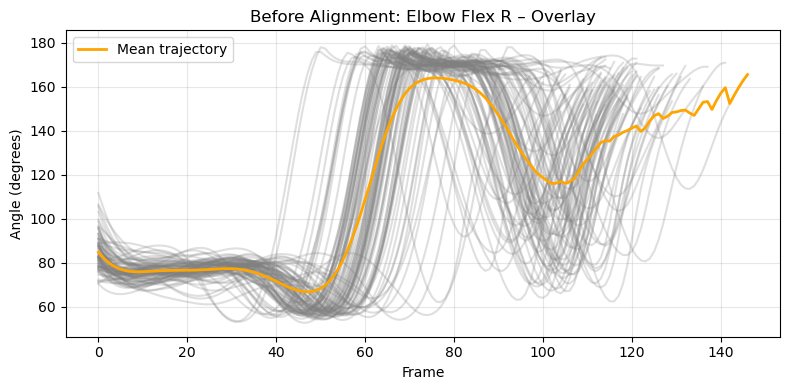

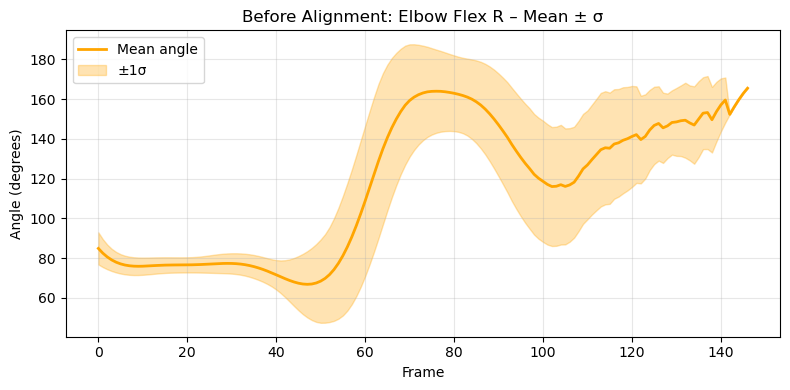

/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:60: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)


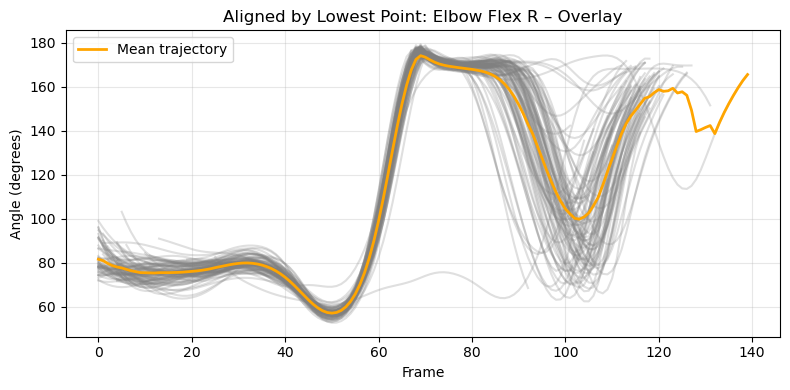

/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:87: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)


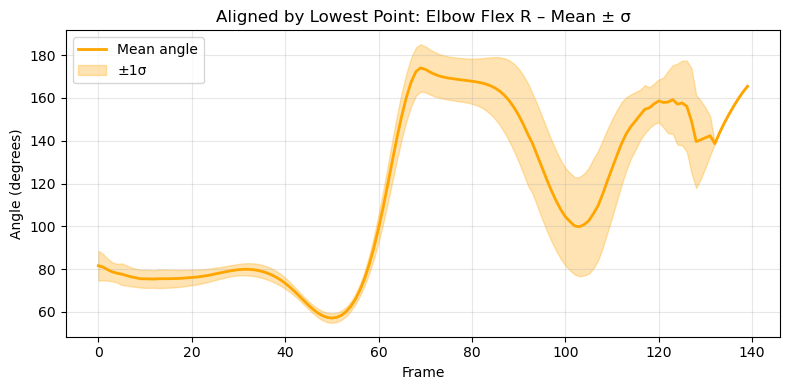

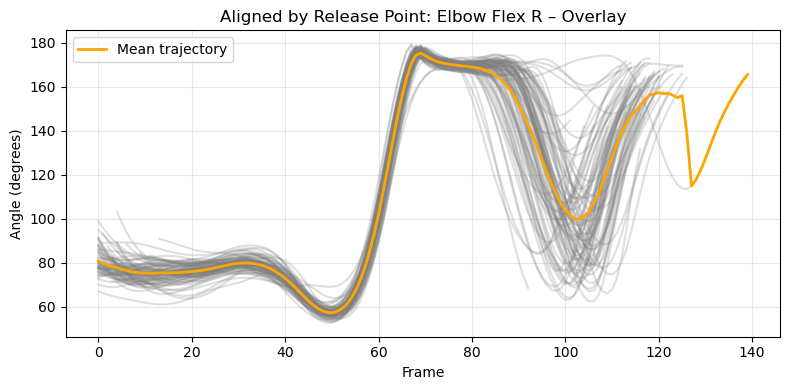

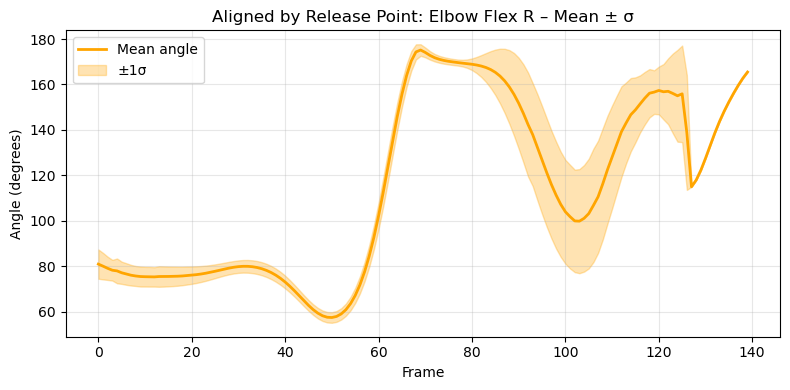

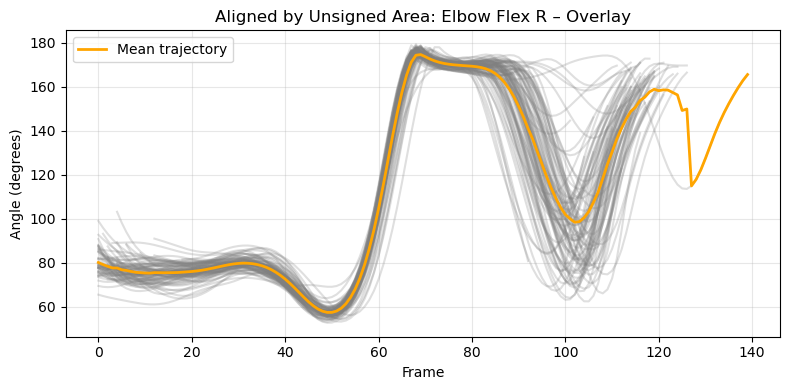

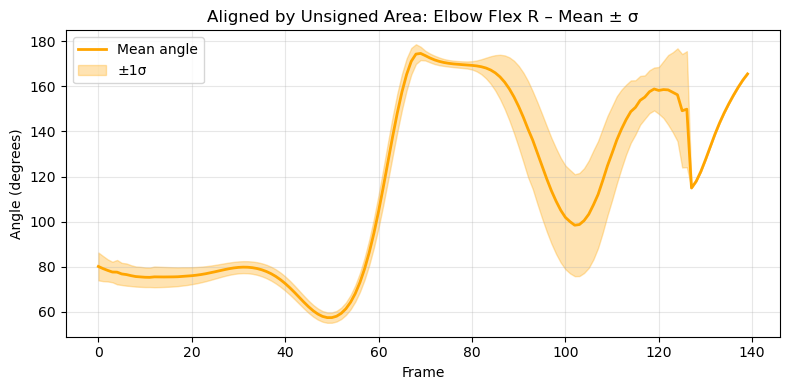

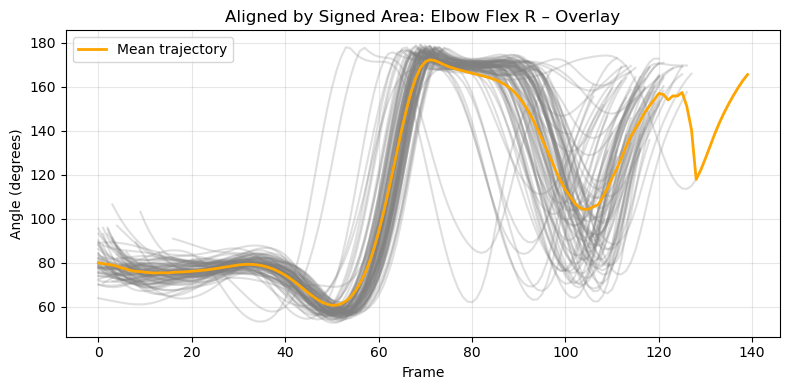

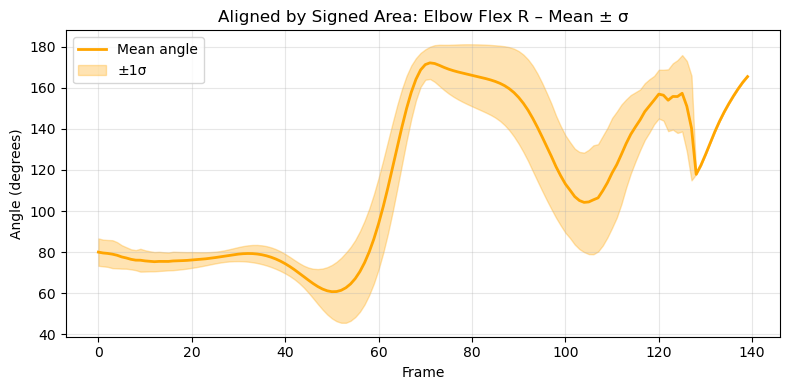

In [7]:
viz = FreeThrowVisualizer()

for joint in selected_joints:

    viz.plot_multiple_joints(
        cropped_angles_dfs,
        selected_joints,
        dataset_name="Before Alignment",
        cropped_phases_df=cropped_phases_df,
        show_overlay=True,
        show_mean_std=True,
        show_release_line=False
    )

    viz.plot_multiple_joints(
        aligned_lowest_point_dfs,
        selected_joints,
        dataset_name="Aligned by Lowest Point",
        cropped_phases_df=cropped_phases_df,
        show_overlay=True,
        show_mean_std=True,
        show_release_line=False
    )

    viz.plot_multiple_joints(
        aligned_release_point_dfs,
        selected_joints,
        dataset_name="Aligned by Release Point",
        cropped_phases_df=cropped_phases_df,
        show_overlay=True,
        show_mean_std=True,
        show_release_line=False
    )

    viz.plot_multiple_joints(
        aligned_unsigned_area_dfs,
        selected_joints,
        dataset_name="Aligned by Unsigned Area",
        cropped_phases_df=cropped_phases_df,
        show_overlay=True,
        show_mean_std=True,
        show_release_line=False
    )

    viz.plot_multiple_joints(
        aligned_signed_area_dfs,
        selected_joints,
        dataset_name="Aligned by Signed Area",
        cropped_phases_df=cropped_phases_df,
        show_overlay=True,
        show_mean_std=True,
        show_release_line=False
    )

    # TODO display number of freethrows being displayed 
    # TODO make a grid of the four types of alignment
    # TODO fix the mess that is visualize_freethrow_utils.py 





In [ ]:
# ===========================================================
# Interactive viewer with green/red consistency dots
# ===========================================================

import ipywidgets as widgets
from IPython.display import display

def review_throw_with_std_band(joint_name, dfs_dict, stats_dict):
    """
    joint_name: e.g. 'elbow_flex_r'
    dfs_dict:   e.g. aligned_unsigned_area_dfs
    stats_dict: output of compute_mean_std_for_alignment(...)
    """

    if joint_name not in stats_dict:
        raise ValueError(f"No stats found for joint '{joint_name}'")

    files = list(dfs_dict.keys())
    joint_stats = stats_dict[joint_name]

    mean  = joint_stats["mean"]
    upper = joint_stats["upper"]
    lower = joint_stats["lower"]
    x     = joint_stats["x"]

    def show(i):
        file = files[i]
        df = dfs_dict[file]

        if joint_name not in df.columns:
            print(f"[WARNING] Joint {joint_name} missing in {file}")
            return
        
        y = df[joint_name].values

        # Pad throw to match mean/std length
        if len(y) < len(mean):
            y = np.pad(y, (0, len(mean) - len(y)), constant_values=np.nan)

        inside = (y >= lower) & (y <= upper)
        valid  = ~np.isnan(y)

        # ========== DRAW BASE GRAPH (mean/std + overlay curves) ==========
        viz = FreeThrowVisualizer(show_overlay=True, show_mean_std=True)
        viz.plot_multiple_joints(
            dfs_dict,
            [joint_name],
            dataset_name=f"Throw {file}",
            cropped_phases_df=None,
            show_overlay=False,
            show_mean_std=True
        )

        # ========== ADD GREEN/RED DOTS ==========

        plt.scatter(x[inside & valid], y[inside & valid],
                    color="green", s=20, label="Inside ±1σ")
        
        plt.scatter(x[~inside & valid], y[~inside & valid],
                    color="red", s=20, label="Outside ±1σ")

        plt.legend()
        plt.show()

    slider = widgets.IntSlider(
        min=0, max=len(files)-1, step=1, value=0,
        description="Throw Index:"
    )
    return widgets.interact(show, i=slider)


viz = FreeThrowVisualizer()

review_throw_with_std_band(
    "elbow_flex_r", 
    aligned_unsigned_area_dfs,
    stats_unsigned_area
)



interactive(children=(IntSlider(value=0, description='Throw Index:', max=88), Output()), _dom_classes=('widget…

<function __main__.review_throw_with_std_band.<locals>.show(i)>

/var/folders/9c/hhbymx8x59sbkqhbr0qtjkr80000gn/T/ipykernel_58749/1489649735.py:63: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/var/folders/9c/hhbymx8x59sbkqhbr0qtjkr80000gn/T/ipykernel_58749/1489649735.py:78: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)


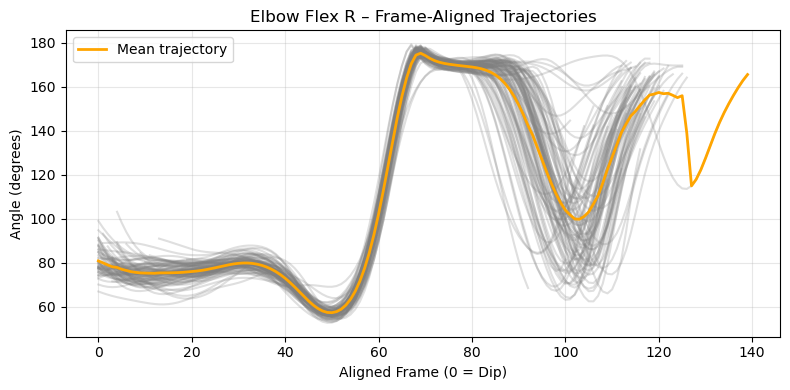

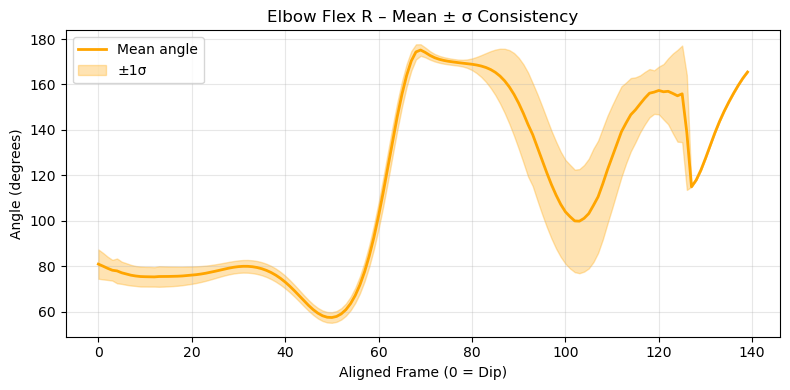

In [9]:
"""
DESCRIPTION:
    - Plot mean ± σ trajectories and overlay all frame-aligned trajectories
      for selected joints across all free throws.
    - Each throw is aligned so frame 0 = dip (lowest elbow flexion before release).
    - X-axis shows aligned frame index (not normalized percentage).
"""

#TODO maybe delte this section 

SHOW_MEAN_STD = True
SHOW_OVERLAY = True

# === CONFIG ===
DISPLAY_ELBOW_FLEX_L = False 
DISPLAY_ELBOW_FLEX_R = True
DISPLAY_SHOULDER_FLEX_L = False
DISPLAY_SHOULDER_FLEX_R = False
DISPLAY_HIP_FLEX_L = False
DISPLAY_HIP_FLEX_R = False
DISPLAY_KNEE_FLEX_L = False
DISPLAY_KNEE_FLEX_R = False
DISPLAY_ANKLE_FLEX_L = False
DISPLAY_ANKLE_FLEX_R = False

joint_flags = {
    "elbow_flex_l": DISPLAY_ELBOW_FLEX_L,
    "elbow_flex_r": DISPLAY_ELBOW_FLEX_R,
    "shoulder_flex_l": DISPLAY_SHOULDER_FLEX_L,
    "shoulder_flex_r": DISPLAY_SHOULDER_FLEX_R,
    "hip_flex_l": DISPLAY_HIP_FLEX_L,
    "hip_flex_r": DISPLAY_HIP_FLEX_R,
    "knee_flex_l": DISPLAY_KNEE_FLEX_L,
    "knee_flex_r": DISPLAY_KNEE_FLEX_R,
    "ankle_flex_l": DISPLAY_ANKLE_FLEX_L,
    "ankle_flex_r": DISPLAY_ANKLE_FLEX_R,
}

# === MAIN LOOP ===
mean_std_store = {}   # joint_name → dict with mean, upper, lower, etc.

for joint_name, display_joint in joint_flags.items():
    if not display_joint:
        continue

    curves = []
    for file_name, df in aligned_release_point_dfs.items():
        if joint_name not in df.columns:
            continue
        curves.append(df[joint_name].to_numpy())

    if not curves:
        continue

    # Pad shorter curves with NaN so all have equal length
    max_len = max(len(c) for c in curves)
    curves = [np.pad(c, (0, max_len - len(c)), constant_values=np.nan) for c in curves]
    curves = np.vstack(curves)


    curves = np.vstack(curves)

    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)
    upper = mean_curve + std_curve
    lower = mean_curve - std_curve

    # 🔥 SAVE FOR LATER USE
    mean_std_store[joint_name] = {
        "mean": mean_curve,
        "std": std_curve,
        "upper": upper,
        "lower": lower
    }
    x = np.arange(curves.shape[1])

    # Compute mean ± std (ignoring NaNs)
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)

    # --- Overlay plot (individual + mean) ---
    if SHOW_OVERLAY:
        plt.figure(figsize=(8, 4))
        for y in curves:
            plt.plot(x, y, color="gray", alpha=0.25)
        plt.plot(x, mean_curve, color="orange", linewidth=2, label="Mean trajectory")
        plt.title(f"{joint_name.replace('_', ' ').title()} – Frame-Aligned Trajectories")
        plt.xlabel("Aligned Frame (0 = Dip)")
        plt.ylabel("Angle (degrees)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # --- Mean ± σ plot ---
    if SHOW_MEAN_STD:
        plt.figure(figsize=(8, 4))
        plt.plot(x, mean_curve, color="orange", linewidth=2, label="Mean angle")
        plt.fill_between(
            x, mean_curve - std_curve, mean_curve + std_curve,
            color="orange", alpha=0.3, label="±1σ"
        )
        plt.title(f"{joint_name.replace('_', ' ').title()} – Mean ± σ Consistency")
        plt.xlabel("Aligned Frame (0 = Dip)")
        plt.ylabel("Angle (degrees)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


In [10]:
# ============================================================
# === CONSISTENCY ANALYSIS: compare each throw to ±1σ band ===
# ============================================================

import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# -----------------------------
# Part 2 — inside/outside logic
# -----------------------------
def compute_within_band(y, lower, upper):
    inside = (y >= lower) & (y <= upper)
    pct_inside = 100 * np.sum(inside) / len(y)
    return inside, pct_inside


# ---------------------------------------------------
# Part 3 — Interactive viewer for individual throws
# ---------------------------------------------------
def review_throw(joint_name):
    files = list(aligned_lowest_point_dfs.keys())

    if joint_name not in mean_std_store:
        raise ValueError(f"No mean/std stored for joint: {joint_name}")

    mean_data = mean_std_store[joint_name]
    mean = mean_data["mean"]
    lower = mean_data["lower"]
    upper = mean_data["upper"]

    def show(i):
        file = files[i]
        df = aligned_lowest_point_dfs[file]

        if joint_name not in df.columns:
            print(f"[WARNING] Joint {joint_name} missing for throw {file}")
            return

        y = df[joint_name].values

        # 🔧 pad y to match mean/std length
        target_len = len(mean)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)), constant_values=np.nan)

        inside, pct_inside = compute_within_band(y, lower, upper)
        x = np.arange(len(mean))

        plt.figure(figsize=(10, 4))
        plt.plot(x, mean, color="blue", linewidth=2, label="Mean")
        plt.fill_between(x, lower, upper, color="green", alpha=0.2, label="±1σ")

        # only evaluate scatter on frames where y is not NaN
        valid = ~np.isnan(y)
        plt.scatter(x[inside & valid], y[inside & valid], color="green", s=14, label="Inside band")
        plt.scatter(x[~inside & valid], y[~inside & valid], color="red", s=14, label="Outside band")

        plt.title(f"{joint_name} – {file}\n{pct_inside:.1f}% inside ±1σ")
        plt.xlabel("Aligned Frame")
        plt.ylabel("Angle (degrees)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
    min=0, max=len(files) - 1, step=1, value=0,
    description="Throw Index:"
    )

    return widgets.interact(show, i=slider)

# -----------------------------------------------------
# Part 4 — Summary table for all throws (joint-level)
# -----------------------------------------------------
def summarize_all_throws(joint_name):
    if joint_name not in mean_std_store:
        raise ValueError(f"No mean/std stored for joint: {joint_name}")

    mean_data = mean_std_store[joint_name]
    lower = mean_data["lower"]
    upper = mean_data["upper"]

    rows = []

    for file, df in aligned_lowest_point_dfs.items():
        if joint_name not in df.columns:
            continue

        y = df[joint_name].values
        inside, pct_inside = compute_within_band(y, lower, upper)

        rows.append((file, pct_inside))

    summary_df = pd.DataFrame(rows, columns=["Throw", "% inside ±1σ"])
    summary_df = summary_df.sort_values("% inside ±1σ", ascending=False)

    return summary_df


# OPTIONAL HELPER: pretty print
def show_summary(joint_name):
    display(summarize_all_throws(joint_name))


review_throw("elbow_flex_r")
# show_summary("elbow_flex_r")


interactive(children=(IntSlider(value=0, description='Throw Index:', max=88), Output()), _dom_classes=('widget…

<function __main__.review_throw.<locals>.show(i)>

In [11]:
# =============================================================
# === EARLY-PHASE TEMPORAL ALIGNMENT USING SIGNED AREA METHOD ===
# =============================================================


# TODO maybe erase this file 

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# -------------------------------------------
# 1. Compute signed area between two curves
# -------------------------------------------
def compute_signed_area(y_throw, y_avg, start, release):
    """Signed area where (throw - average) >0 is positive and <0 is negative."""
    L = min(len(y_throw), len(y_avg))
    y_throw = y_throw[:L]
    y_avg = y_avg[:L]

    diff = y_throw[start:release] - y_avg[start:release]
    return np.sum(diff)

def compute_signed_area_nan_safe(y_throw, y_avg, start, release):
    """Compute signed area ignoring NaNs in either curve."""
    # Slice safely
    diff = y_throw[start:release] - y_avg[start:release]

    # Mask out NaNs
    mask = ~np.isnan(diff)

    if np.sum(mask) == 0:
        return np.inf  # no valid overlapping region

    return np.nansum(diff[mask])


# --------------------------------------------------
# 2. Evaluate area for a range of integer shifts Δt
# --------------------------------------------------
def find_best_shift(y_throw, y_avg, start, release, max_shift=12):
    """
    Finds the optimal time shift Δt using signed area,
    fully supporting NaNs at the beginning/end of curves.
    """

    L = min(len(y_throw), len(y_avg))
    y_throw = y_throw[:L]
    y_avg   = y_avg[:L]

    best_shift = 0
    best_area = np.inf
    results = []

    for d in range(-max_shift, max_shift+1):

        # ---- Apply shift but keep NaN padding behavior ----
        if d > 0:
            shifted = np.r_[np.full(d, np.nan), y_throw[:-d]]
        elif d < 0:
            shifted = np.r_[y_throw[-d:], np.full(-d, np.nan)]
        else:
            shifted = y_throw.copy()

        shifted = shifted[:L]  # ensure same length

        # ---- Compute NaN-safe area ----
        area = compute_signed_area_nan_safe(
            shifted, y_avg, start, release
        )

        results.append((d, area))

        # ---- Choose best shift ----
        if np.isfinite(area) and abs(area) < abs(best_area):
            best_area = area
            best_shift = d

    return best_shift, best_area, results



# --------------------------------------------------
# 3. Visualization of positive/negative signed area
# --------------------------------------------------
def plot_signed_area_comparison(y_throw, y_avg, start, release, shift):
    """Plot original, shifted, and average curves with shaded area."""
    # Shift curve
    if shift > 0:
        y_shifted = y_throw[shift:]
    elif shift < 0:
        y_shifted = np.r_[np.full(-shift, y_throw[0]), y_throw]
    else:
        y_shifted = y_throw.copy()

    L = min(len(y_shifted), len(y_avg))
    y_shifted = y_shifted[:L]
    y_throw = y_throw[:L]
    x = np.arange(L)

    plt.figure(figsize=(12, 4))

    # Average anchor
    plt.plot(x, y_avg[:L], color='orange', linewidth=2, label='Average Curve')

    # Original throw
    plt.plot(x, y_throw, color='gray', alpha=0.5, label='Original Throw')

    # Shifted throw
    plt.plot(x, y_shifted, color='green', alpha=0.7, label=f'Shifted Throw (Δ={shift})')

    # Shading positive/negative area (using shifted curve)
    diff = y_throw[start:release] - y_avg[start:release]

    xs = x[start:release]

    plt.fill_between(xs, y_throw[start:release], y_avg[start:release],
                     where=(diff > 0), color='blue', alpha=0.35,
                     label='Positive Area (ahead)')
    plt.fill_between(xs, y_throw[start:release], y_avg[start:release],
                     where=(diff < 0), color='red', alpha=0.35,
                     label='Negative Area (behind)')

    plt.axvline(start, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(release, color='gray', linestyle='--', alpha=0.5)

    plt.title("Signed Area Alignment Visualization")
    plt.xlabel("Aligned Frame Index")
    plt.ylabel("Angle (degrees)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# 4. Interactive viewer — loop through throws and show alignment
# ------------------------------------------------------------------
def review_alignment(joint_name, phases_df, start_frame=0, max_shift=10):
    """
    Interactive viewer:
    - Fetches the correct release_frame from phases_df per throw.
    - Computes signed-area alignment only up to the true release.
    - Uses NaN-safe shifting.
    """

    files = list(aligned_angles_dfs.keys())
    mean_curve = mean_std_store[joint_name]["mean"]

    # Precompute base names for fast lookup
    phases_df = phases_df.copy()
    phases_df["base_name"] = phases_df["file"].apply(extract_base_freethrow_name)

    def show(i):
        file = files[i]
        df = aligned_angles_dfs[file]
        base = extract_base_freethrow_name(file)

        if joint_name not in df.columns:
            print(f"[WARNING] Joint {joint_name} missing for throw {file}")
            return

        # --- Get the true release frame from phases_df ---
        match = phases_df[phases_df["base_name"] == base]

        if match.empty:
            print(f"[ERROR] No release frame found for {file}")
            return

        release_frame = int(match["release_frame"].values[0])

        # --- Extract data ---
        y = df[joint_name].values

        # --- Compute best shift ---
        best_shift, best_area, results = find_best_shift(
            y, mean_curve, start_frame, release_frame, max_shift=max_shift
        )

        print(f"Throw: {file}")
        print(f"Release frame: {release_frame}")
        print(f"Best Δ shift = {best_shift} frames   (Area = {best_area:.2f})")

        # --- Plot (using true release frame) ---
        plot_signed_area_comparison(y, mean_curve, start_frame, release_frame, best_shift)

    slider = widgets.IntSlider(
        min=0, max=len(files) - 1, step=1, value=0,
        description="Throw Index:"
    )

    return widgets.interact(show, i=slider)


review_alignment("elbow_flex_r", phases_df, start_frame=0)



NameError: name 'phases_df' is not defined

In [ ]:
"""
DESCRIPTION:
    - Plot mean ± σ trajectories (Option 1) and overlayed normalized trajectories (Option 2)
      for selected joints across all free throws.
    - Each throw is time-normalized to 0–100%.
    - Saves per-joint summary stats to a CSV database at the end.
"""

# === CONFIG ===
NUM_SAMPLES = 100  # how many time-normalized points per throw
SHOW_MEAN_STD = True
SHOW_OVERLAY = True

# === Joint display flags ===
DISPLAY_ELBOW_FLEX_L = False 
DISPLAY_ELBOW_FLEX_R = True
DISPLAY_SHOULDER_FLEX_L = False
DISPLAY_SHOULDER_FLEX_R = False
DISPLAY_HIP_FLEX_L = False
DISPLAY_HIP_FLEX_R = False
DISPLAY_KNEE_FLEX_L = False
DISPLAY_KNEE_FLEX_R = False
DISPLAY_ANKLE_FLEX_L = False
DISPLAY_ANKLE_FLEX_R = False

joint_flags = {
    "elbow_flex_l": DISPLAY_ELBOW_FLEX_L,
    "elbow_flex_r": DISPLAY_ELBOW_FLEX_R,
    "shoulder_flex_l": DISPLAY_SHOULDER_FLEX_L,
    "shoulder_flex_r": DISPLAY_SHOULDER_FLEX_R,
    "hip_flex_l": DISPLAY_HIP_FLEX_L,
    "hip_flex_r": DISPLAY_HIP_FLEX_R,
    "knee_flex_l": DISPLAY_KNEE_FLEX_L,
    "knee_flex_r": DISPLAY_KNEE_FLEX_R,
    "ankle_flex_l": DISPLAY_ANKLE_FLEX_L,
    "ankle_flex_r": DISPLAY_ANKLE_FLEX_R,
}

# === Helper: normalize to same number of samples ===
def normalize_series_with_nans(y, num_points=NUM_SAMPLES):
    """Interpolate to a fixed number of samples, keeping NaN padding influence."""
    valid = ~np.isnan(y)
    if valid.sum() < 5:
        return None
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, num_points)
    # interpolate using only valid data range
    return np.interp(x_new, x_old[valid], y[valid])

# === Initialize summary ===
joint_summaries = []

# === Loop through joints ===
for joint_name, display_joint in joint_flags.items():
    if not display_joint:
        continue

    normalized_curves = []

    for file_name, df in aligned_angles_dfs.items():  # using aligned data
        if joint_name not in df.columns:
            continue

        y = df[joint_name].to_numpy()
        normalized = normalize_series_with_nans(y)
        if normalized is not None:
            normalized_curves.append(normalized)

    if not normalized_curves:
        print(f"[WARNING] No data found for {joint_name}")
        continue

    # === Stack and compute stats ===
    curves = np.vstack(normalized_curves)
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)
    x = np.linspace(0, 100, NUM_SAMPLES)

    # === Plot overlay ===
    if SHOW_OVERLAY:
        plt.figure(figsize=(7, 4))
        for y in curves:
            plt.plot(x, y, color="gray", alpha=0.2)
        plt.plot(x, mean_curve, color="orange", linewidth=2, label="Mean trajectory")
        plt.title(f"{joint_name.replace('_', ' ').title()} – Normalized Trajectories")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (degrees)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # === Plot mean ± σ ===
    if SHOW_MEAN_STD:
        plt.figure(figsize=(7, 4))
        plt.plot(x, mean_curve, color="orange", linewidth=2, label="Mean angle")
        plt.fill_between(
            x, mean_curve - std_curve, mean_curve + std_curve,
            color="orange", alpha=0.3, label="±1σ"
        )
        plt.title(f"{joint_name.replace('_', ' ').title()} – Mean ± σ Consistency")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (degrees)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


In [ ]:
"""
DESCRIPTION:
    - Plot mean ± σ trajectories (Option 1) and overlayed normalized trajectories (Option 2)
      for selected joints across all free throws.
    - Each throw is time-normalized to 0–100%.
    - Uses outcomes.csv to separate made vs missed shots.
"""

# === CONFIG ===
NUM_SAMPLES = 100
SHOW_MEAN_STD = True
SHOW_OVERLAY = True

# === Joint display flags ===
joint_flags = {
    "elbow_flex_l": DISPLAY_ELBOW_FLEX_L,
    "elbow_flex_r": DISPLAY_ELBOW_FLEX_R,
    "shoulder_flex_l": DISPLAY_SHOULDER_FLEX_L,
    "shoulder_flex_r": DISPLAY_SHOULDER_FLEX_R,
    "hip_flex_l": DISPLAY_HIP_FLEX_L,
    "hip_flex_r": DISPLAY_HIP_FLEX_R,
    "knee_flex_l": DISPLAY_KNEE_FLEX_L,
    "knee_flex_r": DISPLAY_KNEE_FLEX_R,
    "ankle_flex_l": DISPLAY_ANKLE_FLEX_L,
    "ankle_flex_r": DISPLAY_ANKLE_FLEX_R,
}

# === Helper: normalize each throw to same number of samples ===
def normalize_series(series, num_points=NUM_SAMPLES):
    """Interpolate a 1D array to a fixed number of equally spaced points."""
    x_old = np.linspace(0, 1, len(series))
    x_new = np.linspace(0, 1, num_points)
    return np.interp(x_new, x_old, series)

# === Load outcomes file ===
outcomes_path = metrics_path / "outcomes.csv"
outcomes_df = pd.read_csv(outcomes_path)

# Clean and normalize names for matching
outcomes_df["file_base"] = (
    outcomes_df["file"]
    .str.replace(".avi", "", regex=False)
    .str.replace(".csv", "", regex=False)
    .str.strip()
    .str.lower()
)
outcomes_df["outcome"] = outcomes_df["outcome"].str.lower().str.strip()

# === Loop through selected joints ===
for joint_name, display_joint in joint_flags.items():
    if not display_joint:
        continue

    curves_make, curves_miss = [], []

    for file_name, df in cropped_angles_dfs.items():
        base_name = file_name.lower().strip()
        match = outcomes_df[outcomes_df["file_base"] == base_name]

        if match.empty or joint_name not in df.columns:
            continue

        y = df[joint_name].dropna().values
        if len(y) < 5:
            continue

        normalized = normalize_series(y)
        outcome = match["outcome"].iloc[0]

        if outcome == "made":
            curves_make.append(normalized)
        elif outcome == "missed" or outcome == "miss":
            curves_miss.append(normalized)

    if not curves_make and not curves_miss:
        print(f"[WARNING] No data for {joint_name}")
        continue

    x = np.linspace(0, 100, NUM_SAMPLES)

    # === Helper for mean/std ===
    def mean_std(curves):
        if len(curves) == 0:
            return None, None
        arr = np.vstack(curves)
        return arr.mean(axis=0), arr.std(axis=0)

    mean_make, std_make = mean_std(curves_make)
    mean_miss, std_miss = mean_std(curves_miss)

    # === Option 1 – Overlay all trajectories ===
    if SHOW_OVERLAY:
        plt.figure(figsize=(7, 4))

        # individual trajectories
        for y in curves_make:
            plt.plot(x, y, color="green", alpha=0.15)
        for y in curves_miss:
            plt.plot(x, y, color="red", alpha=0.15)

        # mean lines
        if mean_make is not None:
            plt.plot(x, mean_make, color="green", linewidth=2.5, label="Make (mean)")
        if mean_miss is not None:
            plt.plot(x, mean_miss, color="red", linewidth=2.5, label="Miss (mean)")

        plt.title(f"{joint_name.replace('_',' ').title()} – Normalized Trajectories")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (°)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # === Option 2 – Mean ± σ ===
    if SHOW_MEAN_STD:
        plt.figure(figsize=(7, 4))

        # Makes
        if mean_make is not None:
            plt.plot(x, mean_make, color="green", linewidth=2.5, label="Make (mean)")
            plt.fill_between(x, mean_make - std_make, mean_make + std_make,
                             color="green", alpha=0.25, label="Make ±1σ")

        # Misses
        if mean_miss is not None:
            plt.plot(x, mean_miss, color="red", linewidth=2.5, label="Miss (mean)")
            plt.fill_between(x, mean_miss - std_miss, mean_miss + std_miss,
                             color="red", alpha=0.25, label="Miss ±1σ")

        plt.title(f"{joint_name.replace('_',' ').title()} – Mean ± σ Consistency")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (°)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # === Print summary ===
    def describe(curves):
        if not curves:
            return "n/a"
        arr = np.vstack(curves)
        mean_val = arr.mean()
        std_val = arr.std()
        cv = (std_val / mean_val) * 100 if mean_val != 0 else 0
        return f"avg STD = {std_val:.2f}, CV = {cv:.1f}%"

    print(f"{joint_name}: {len(curves_make)} makes, {len(curves_miss)} misses")
    print(f"   Makes:  {describe(curves_make)}")
    print(f"   Misses: {describe(curves_miss)}\n")


In [ ]:
# === Multi-Joint Coordination Plot with Release Window + Peak Annotations ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- choose which joints to compare and whether to show faint overlays ---
COMPARE_JOINTS = ["knee_flex_r", "elbow_flex_r", "shoulder_flex_r"]
SHOW_INDIVIDUAL_OVERLAYS = True

# --- pick if you want to look for min/max for given angle ---
EXTREMUM = {
    "knee_flex_r": "min",      
    "knee_flex_l": "min",
    "elbow_flex_r": "max",
    "elbow_flex_l": "max",
    "shoulder_flex_r": "max",
    "shoulder_flex_l": "max",
    "hip_flex_r": "min",       
    "hip_flex_l": "min",
    "ankle_flex_r": "min",
    "ankle_flex_l": "min",
}

def extremum_index(curve, which="max"):
    return int(np.argmax(curve)) if which == "max" else int(np.argmin(curve))

# --- helper to collect normalized curves + mean/std for one joint ---
def collect_joint_curves(joint_name, num_points=100):
    curves = []
    for file_name, df in cropped_angles_dfs.items():
        if joint_name not in df.columns:
            continue
        y = df[joint_name].dropna().values
        if len(y) < 5:
            continue
        curves.append(normalize_series(y, num_points))
    if not curves:
        return None, None, None
    curves = np.vstack(curves)
    mean_curve = curves.mean(axis=0)
    std_curve  = curves.std(axis=0, ddof=1)
    return curves, mean_curve, std_curve

# --- compute normalized release % per throw (0–100%) ---
release_percents = []
for file_name, df in cropped_angles_dfs.items():
    base = file_name.split("_angles")[0]
    row = phases_df[phases_df["file"].str.contains(base, na=False)]
    if row.empty:
        continue
    ws, rel, fe = row[["windup_start","release_frame","followthrough_end"]].values[0]
    if pd.isna(ws) or pd.isna(rel) or pd.isna(fe):
        continue
    ws, rel, fe = int(ws), int(rel), int(fe)
    total = max(fe - ws, 1)
    pct = 100.0 * (rel - ws) / total
    # keep only sane values
    if np.isfinite(pct) and -50 <= pct <= 150:
        release_percents.append(pct)

if len(release_percents) == 0:
    print("[WARNING] No valid release timings found.")
    rel_mean, rel_std = 50.0, 0.0
else:
    rel_mean = float(np.mean(release_percents))
    rel_std  = float(np.std(release_percents, ddof=1))

# --- collect curves for requested joints ---
joint_mean_curves = {}
joint_std_curves  = {}
joint_all_curves  = {}

for j in COMPARE_JOINTS:
    curves, m, s = collect_joint_curves(j, NUM_SAMPLES)
    if curves is None:
        print(f"[⚠️] No data for {j}, skipping.")
        continue
    joint_all_curves[j]  = curves
    joint_mean_curves[j] = m
    joint_std_curves[j]  = s

# --- plot ---
x = np.linspace(0, 100, NUM_SAMPLES)
plt.figure(figsize=(9, 5))

# distinct colors for each joint
color_cycle = plt.cm.tab10(np.linspace(0, 1, max(3, len(joint_mean_curves))))
for i, j in enumerate(joint_mean_curves.keys()):
    color = color_cycle[i]
    # faint per-throw overlays (matching the joint color)
    if SHOW_INDIVIDUAL_OVERLAYS:
        for curve in joint_all_curves[j]:
            plt.plot(x, curve, color=color, alpha=0.06, linewidth=1)

    # mean line
    plt.plot(x, joint_mean_curves[j], color=color, linewidth=2.8,
             label=j.replace("_", " ").title())

# release mean (line) + ±1σ (span)
plt.axvline(rel_mean, linestyle="--", linewidth=1.5, color="black",
            label=f"Release ≈ {rel_mean:.0f}%")
if rel_std > 0:
    plt.axvspan(rel_mean - rel_std, rel_mean + rel_std, color="black", alpha=0.08,
                label="Release ±1σ")

plt.title("Multi-Joint Coordination: Mean Trajectories")
plt.xlabel("Normalized Motion (%)")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- annotate peaks and print timing table vs release ---
print("\nPeak timing (mean trajectory) and delta to release:")
peak_marks = []
for i, j in enumerate(joint_mean_curves.keys()):
    curve = joint_mean_curves[j]
    which = EXTREMUM.get(j, "max")
    idx = extremum_index(curve, which)
    t_peak = x[idx]
    val    = curve[idx]
    peak_marks.append((j, t_peak, val, which))

# pretty print
for j, t_peak, val, which in peak_marks:
    print(f"• {j.replace('_',' ').title():16s} peak({which:3s}) at {t_peak:5.1f}%"
          f"  | value {val:6.1f}°  | change to release {t_peak - rel_mean:+5.1f}%")

# (optional) re-draw just the markers on top of the last figure:
plt.figure(figsize=(9, 5))
for i, j in enumerate(joint_mean_curves.keys()):
    color = color_cycle[i]
    plt.plot(x, joint_mean_curves[j], color=color, linewidth=2.8,
             label=j.replace("_", " ").title())
    # marker
    which = EXTREMUM.get(j, "max")
    idx = extremum_index(joint_mean_curves[j], which)
    plt.scatter([x[idx]], [joint_mean_curves[j][idx]], color=color, s=35, zorder=5)

plt.axvline(rel_mean, linestyle="--", linewidth=1.5, color="black",
            label=f"Release ≈ {rel_mean:.0f}%")
if rel_std > 0:
    plt.axvspan(rel_mean - rel_std, rel_mean + rel_std, color="black", alpha=0.08,
                label="Release ±1σ")

plt.title("Multi-Joint Coordination with Peaks + Release Window")
plt.xlabel("Normalized Motion (%)")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
"""
DESCRIPTION:
    - Plot mean ± σ trajectories (Option 1) and overlayed normalized trajectories (Option 2)
      for selected joints across all free throws.
    - Computes per-throw deviation metrics to detect outliers (RMS error, dynamic range, etc.)
    - Highlights outliers visually with labels (O1, O2, …) and saves them in CSV reports.
"""

# === CONFIG ===
NUM_SAMPLES = 100
SHOW_MEAN_STD = False
SHOW_OVERLAY = False
Z_THRESHOLD = 2.0  # outlier threshold in standard deviations
LABEL_OFFSET = 2   # offset in y for text labels

# === Helper functions ===
def normalize_series(series, num_points=NUM_SAMPLES):
    x_old = np.linspace(0, 1, len(series))
    x_new = np.linspace(0, 1, num_points)
    return np.interp(x_new, x_old, series)

def rms_error(curve, mean_curve):
    return np.sqrt(np.mean((curve - mean_curve) ** 2))

def dynamic_range(curve):
    return np.max(curve) - np.min(curve)

# === Load outcomes ===
outcomes_path = metrics_path / "outcomes.csv"
outcomes_df = pd.read_csv(outcomes_path)
outcomes_df["file_base"] = (
    outcomes_df["file"]
    .str.replace(".avi", "", regex=False)
    .str.replace(".csv", "", regex=False)
    .str.strip()
    .str.lower()
)
outcomes_df["outcome"] = outcomes_df["outcome"].str.lower().str.strip()

# === Main loop ===
for joint_name, display_joint in joint_flags.items():
    if not display_joint:
        continue

    curves_make, file_make = [], []
    for file_name, df in cropped_angles_dfs.items():
        base_name = file_name.lower().strip()
        match = outcomes_df[outcomes_df["file_base"] == base_name]
        if match.empty or joint_name not in df.columns:
            continue

        y = df[joint_name].dropna().values
        if len(y) < 5:
            continue
        normalized = normalize_series(y)

        if match["outcome"].iloc[0] == "made" or "miss":
            curves_make.append(normalized)
            file_make.append(base_name)

    if not curves_make:
        print(f"[WARNING] No makes for {joint_name}")
        continue

    # === Compute mean and deviation metrics ===
    x = np.linspace(0, 100, NUM_SAMPLES)
    arr = np.vstack(curves_make)
    mean_curve = np.mean(arr, axis=0)
    std_curve = np.std(arr, axis=0)

    # Compute per-throw metrics
    metrics = []
    for fname, curve in zip(file_make, curves_make):
        rms = rms_error(curve, mean_curve)
        range_ratio = dynamic_range(curve) / dynamic_range(mean_curve)
        peak_diff = np.max(np.abs(curve - mean_curve))
        metrics.append((fname, rms, range_ratio, peak_diff))

    metrics_df = pd.DataFrame(metrics, columns=["file", "rms_error", "range_ratio", "peak_diff"])
    metrics_df["z_rms"] = (metrics_df["rms_error"] - metrics_df["rms_error"].mean()) / metrics_df["rms_error"].std()
    metrics_df["is_outlier"] = metrics_df["z_rms"].abs() > Z_THRESHOLD

    # Assign outlier IDs (O1, O2, etc.)
    outlier_indices = np.where(metrics_df["is_outlier"])[0]
    metrics_df.loc[metrics_df["is_outlier"], "outlier_label"] = [
        f"O{i+1}" for i in range(len(outlier_indices))
    ]

    # === Plot overlays with labeled outliers ===
    if SHOW_OVERLAY:
        plt.figure(figsize=(7, 4))
        for i, curve in enumerate(curves_make):
            if metrics_df["is_outlier"].iloc[i]:
                label = metrics_df["outlier_label"].iloc[i]
                plt.plot(x, curve, color="black", linewidth=1.6)
                # Label near max value to reduce overlap
                y_max_idx = np.argmax(curve)
                plt.text(x[y_max_idx], curve[y_max_idx] + LABEL_OFFSET, label,
                         fontsize=9, color="black", weight="bold")
            else:
                plt.plot(x, curve, color="green", alpha=0.15)

        plt.plot(x, mean_curve, color="orange", linewidth=2.5, label="Mean")
        plt.title(f"{joint_name.replace('_',' ').title()} – Outlier Highlighting (Makes and misses)")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (°)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # === Plot mean ± σ with labeled outliers ===
    if SHOW_MEAN_STD:
        plt.figure(figsize=(7, 4))
        plt.plot(x, mean_curve, color="orange", linewidth=2.5, label="Mean")
        plt.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                         color="orange", alpha=0.25, label="±1σ")

        for i, curve in enumerate(curves_make):
            if metrics_df["is_outlier"].iloc[i]:
                label = metrics_df["outlier_label"].iloc[i]
                plt.plot(x, curve, color="black", linewidth=1.3, alpha=0.7)
                y_max_idx = np.argmax(curve)
                plt.text(x[y_max_idx], curve[y_max_idx] + LABEL_OFFSET, label,
                         fontsize=9, color="black", weight="bold")

        plt.title(f"{joint_name.replace('_',' ').title()} – Mean ± σ + Outliers")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (°)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # === Save report ===
    metrics_path_out = metrics_path / f"outliers_{joint_name}.csv"
    metrics_df.sort_values("rms_error", ascending=False).to_csv(metrics_path_out, index=False)
    print(f"✅ Saved outlier report: {metrics_path_out.name}")
    print(metrics_df[metrics_df["is_outlier"]][["file", "rms_error", "z_rms", "outlier_label"]].head(), "\n")


In [ ]:
def plot_angles_over_frames(angles_long_df, session_id: str, use_seconds: bool = False, files=None):
    """
    Interactive Plotly function:
    - Plots all joint angles for one free throw at a time.
    - Use the slider (animation) to step through throws by filename.
    - Keeps consistent axis ranges across all throws.
    """

    # --- Filter to this session ---
    df = angles_long_df[angles_long_df['session'] == session_id].copy()

    # --- Optional file filtering ---
    if files is not None:
        if isinstance(files, (list, tuple, set)):
            df = df[df['file'].isin(files)]
        elif isinstance(files, str):
            df = df[df['file'].str.contains(files)]
        else:
            raise ValueError("`files` must be None, a list, or a string pattern.")

    # --- Determine x-axis (frames or seconds) ---
    xcol = "time_s" if use_seconds and "time_s" in df.columns else "frame"

    # --- Compute consistent axis ranges ---
    x_min, x_max = df[xcol].min(), df[xcol].max()
    y_min, y_max = df["value"].min(), df["value"].max()

    # --- Create interactive line plot ---
    fig = px.line(
        df,
        x=xcol,
        y="value",
        color="angle",
        animation_frame="file",
        animation_group="angle",
        hover_data=["file", "angle", "frame", "session"],
    )

    # --- Keep consistent axis scales for all frames ---
    fig.update_layout(
        title=f"All Angles — {session_id} (use slider to step through throws)",
        xaxis_title=("Time (s)" if xcol == "time_s" else "Frame"),
        yaxis_title="Angle (°)",
        legend_title="Angle",
        hovermode="x unified",
        template="plotly_white",
        xaxis_range=[x_min, x_max],
        yaxis_range=[y_min - 5, y_max + 5],
    )

    # --- Fix for some browsers cutting off frame updates ---
    fig.layout.updatemenus[0].buttons[0].args[1]['frame']['redraw'] = True

    return fig


# Example usage
sample_files = list(cropped_angles_dfs.keys())
fig = plot_angles_over_frames(
    angles_long_df=cropped_angles_long_df, 
    session_id=SESSION, 
    files=sample_files,
    use_seconds=False
)
fig.show()
